# Financial Returns Prediction with LSTM (MLX)

This notebook mirrors the XGBoost workflow (`513_financial_xgboost.ipynb`) but trains sequence models using **MLX** (Apple Silicon). It keeps the same data prep and feature definitions so you can compare models side-by-side.

> Requires the MLX package (Apple Silicon). Install if needed: `pip install mlx` (and optionally `pip install mlx-lm`).

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import mlx.core as mx
import mlx.nn as nn
from mlx.optimizers import AdamW

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Display and plotting options
pd.options.display.float_format = "{:.4f}".format
plt.rcParams["figure.figsize"] = (12, 4)

DATA_DIR = "./data/"
OUTPUT_DIR = "./data/"

RAW_FINANCIAL_FILE = DATA_DIR + "market_data.json"
EPI_FILE = DATA_DIR + "epi_data.json"

# Analysis window (same as XGBoost notebook)
START_DATE = "2025-01-01"
END_DATE = "2025-05-31"

np.random.seed(42)
mx.random.seed(42)


## 1. Load and Prepare Data

In [2]:

# --- Load raw financial data ---
try:
    df_raw = pd.read_json(RAW_FINANCIAL_FILE)
except ValueError:
    df_raw = pd.read_csv(RAW_FINANCIAL_FILE)

if "Date_" not in df_raw.columns:
    raise KeyError("Expected a 'Date_' column in the market data file.")

# Parse dates and sort
df_raw["Date_"] = pd.to_datetime(df_raw["Date_"])
df_raw = df_raw.sort_values("Date_").set_index("Date_")

# Rename columns to simpler names (matches XGBoost notebook)
rename_map = {
    "Close_BTC-USD": "close_btc",
    "Close_GC=F": "close_gold",
    "Close_CL=F": "close_oil",
    "Close_^GSPC": "close_spx",
    "Close_CNY=X": "close_usdcny",
    "Close_EUR=X": "close_eurusd",
    "Close_^TNX": "close_ust10y",
    "Volume_BTC-USD": "vol_btc",
    "Volume_GC=F": "vol_gold",
    "Volume_^GSPC": "vol_spx",
}

df = df_raw.rename(columns=rename_map)

# Create business-day index and forward-fill prices
full_index = pd.date_range(df.index.min(), df.index.max(), freq="B")
df = df.reindex(full_index)
price_cols = [c for c in df.columns if c.startswith("close_")]
df[price_cols] = df[price_cols].ffill()

# Construct returns and control variables
def log_return(series):
    return np.log(series).diff()

returns = pd.DataFrame(index=df.index)
returns["r_btc"] = log_return(df["close_btc"])
returns["r_gold"] = log_return(df["close_gold"])
returns["r_spx"] = log_return(df["close_spx"])

returns["dln_eurusd"] = log_return(df["close_eurusd"])
returns["dln_usdcny"] = log_return(df["close_usdcny"])
returns["dln_oil"] = log_return(df["close_oil"])
returns["dy10"] = df["close_ust10y"].diff()

returns = returns.dropna().loc[START_DATE:END_DATE]

# Load EPI data
df_epi = pd.read_json(EPI_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

epi_cols = [col for col in df_epi.columns if col.startswith('epi') or col in ['ei_creator', 'ei_community']]

returns = returns.join(df_epi[epi_cols], how='left')
returns[epi_cols] = returns[epi_cols].fillna(0)

print(f"Data window: {returns.index.min().date()} to {returns.index.max().date()}")
print(f"Columns: {returns.columns.tolist()}")


Data window: 2025-01-01 to 2025-05-30
Columns: ['r_btc', 'r_gold', 'r_spx', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'ei_creator', 'ei_community', 'epi', 'epi_weighted', 'epi_', 'epi_Environmental and Infrastructure', 'epi_Labor and Workforce', 'epi_Health and Social Welfare', 'epi_Legal and Regulatory Framework', 'epi_Education and Knowledge', 'epi_Psychological and Emotional Aspects', 'epi_Leadership and Governance', 'epi_Economic and Financial Matters', 'epi_Disaster and Resilience', 'epi_Security and Conflict', 'epi_Disputes and Opinions', 'epi_Miscellaneous and Other', 'epi_Sports and Recreation', 'epi_Power and Influence Dynamics', 'epi_Social and Cultural Aspects', 'epi_Quality of Life and Standards', 'epi_Trust, Credibility, and Communication', 'epi_Conspiracy and Historical Events']


## 2. Feature Engineering (lags, asymmetry, rolling stats)

In [3]:

max_lag = 5
data = returns.copy()

for asset in ["r_btc", "r_gold", "r_spx"]:
    for lag in range(1, max_lag + 1):
        data[f"{asset}_l{lag}"] = data[asset].shift(lag)

for lag in range(1, max_lag + 1):
    data[f'epi_l{lag}'] = data['epi'].shift(lag)
    data[f'epi_weighted_l{lag}'] = data['epi_weighted'].shift(lag)

# Asymmetric and rolling stats
data['epi_pos'] = np.maximum(data['epi'], 0)
data['epi_neg'] = np.minimum(data['epi'], 0)
data['epi_weighted_pos'] = np.maximum(data['epi_weighted'], 0)
data['epi_weighted_neg'] = np.minimum(data['epi_weighted'], 0)

data['epi_ma5'] = data['epi'].rolling(5).mean()
data['epi_std5'] = data['epi'].rolling(5).std()
data['epi_weighted_ma5'] = data['epi_weighted'].rolling(5).mean()
data['epi_weighted_std5'] = data['epi_weighted'].rolling(5).std()

for asset in ["r_btc", "r_gold", "r_spx"]:
    data[f"{asset}_vol5"] = data[asset].rolling(5).std()

data = data.dropna()
print(f"Feature-engineered data shape: {data.shape}")


Feature-engineered data shape: (103, 66)


## 3. Feature Sets (same definitions as XGBoost notebook)

In [4]:

control_cols = ["dln_eurusd", "dln_usdcny", "dln_oil", "dy10"]


def get_feature_cols(asset, model_type="baseline"):
    """
    Return feature columns for each model type.
    - baseline: lagged returns + controls + vol
    - epi / epi_weighted: add contemporaneous EPI variant
    - epi_lagged: add EPI lags
    - epi_full: asymmetric + lags + rolling stats
    - epi_weighted_full: weighted version of epi_full
    """
    lag_cols = [f"{asset}_l{lag}" for lag in range(1, 4)]
    other_assets = [a for a in ["r_btc", "r_gold", "r_spx"] if a != asset]
    cross_cols = [f"{a}_l1" for a in other_assets]
    vol_cols = [f"{asset}_vol5"]
    base_features = lag_cols + cross_cols + control_cols + vol_cols

    if model_type == "baseline":
        return base_features
    if model_type == "epi":
        return base_features + ["epi"]
    if model_type == "epi_weighted":
        return base_features + ["epi_weighted"]
    if model_type == "epi_lagged":
        epi_lags = [f"epi_l{lag}" for lag in range(1, 4)]
        return base_features + epi_lags
    if model_type == "epi_asymmetric":
        return base_features + ["epi_pos", "epi_neg"]
    if model_type == "epi_full":
        epi_lags = [f"epi_l{lag}" for lag in range(1, 4)]
        epi_roll = ["epi_ma5", "epi_std5"]
        return base_features + ["epi", "epi_pos", "epi_neg"] + epi_lags + epi_roll
    if model_type == "epi_weighted_full":
        epi_lags = [f"epi_weighted_l{lag}" for lag in range(1, 4)]
        epi_roll = ["epi_weighted_ma5", "epi_weighted_std5"]
        return base_features + ["epi_weighted", "epi_weighted_pos", "epi_weighted_neg"] + epi_lags + epi_roll
    raise ValueError(f"Unknown model type: {model_type}")

print(get_feature_cols("r_btc", "epi_full"))


['r_btc_l1', 'r_btc_l2', 'r_btc_l3', 'r_gold_l1', 'r_spx_l1', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'r_btc_vol5', 'epi', 'epi_pos', 'epi_neg', 'epi_l1', 'epi_l2', 'epi_l3', 'epi_ma5', 'epi_std5']


## 4. MLX LSTM helpers (sequence builder, model, training loop)

In [17]:
from typing import Dict, List, Tuple, Optional
import copy
import mlx.utils


def make_sequences(features: np.ndarray, targets: np.ndarray, seq_len: int, index: pd.Index):
    X_seq, y_seq, seq_dates = [], [], []
    for i in range(seq_len, len(features)):
        X_seq.append(features[i - seq_len : i])
        y_seq.append(targets[i])
        seq_dates.append(index[i])
    return (
        np.array(X_seq, dtype=np.float32),
        np.array(y_seq, dtype=np.float32),
        pd.Index(seq_dates),
    )


def compute_metrics(actuals: np.ndarray, preds: np.ndarray) -> Dict[str, float]:
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    # Handle zero returns for directional accuracy
    mask = actuals != 0
    if mask.sum() > 0:
        dir_acc = np.mean(np.sign(actuals[mask]) == np.sign(preds[mask])) * 100
    else:
        dir_acc = 50.0
    return {"rmse": rmse, "mae": mae, "dir_acc": dir_acc}


def copy_weights(weights):
    """Deep copy model weights (nested dict of arrays)."""
    return mlx.utils.tree_map(lambda x: mx.array(x), weights)


class TemporalAttention(nn.Module):
    """Simple attention over timesteps to focus on important periods."""
    
    def __init__(self, hidden_size: int):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)
    
    def __call__(self, x):
        # x: (batch, seq_len, hidden)
        scores = self.attention(x)  # (batch, seq_len, 1)
        weights = mx.softmax(scores, axis=1)
        # Weighted sum over timesteps
        context = mx.sum(x * weights, axis=1)  # (batch, hidden)
        return context, weights


class ImprovedLSTMRegressor(nn.Module):
    """Enhanced LSTM with attention, layer norm, and residual connections."""

    def __init__(
        self, 
        input_size: int, 
        hidden_size: int = 64, 
        num_layers: int = 2, 
        dropout: float = 0.2,
        use_attention: bool = True,
        use_layer_norm: bool = True,
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout_rate = dropout
        self.use_attention = use_attention
        self.use_layer_norm = use_layer_norm
        
        # Input projection for residual
        self.input_proj = nn.Linear(input_size, hidden_size) if input_size != hidden_size else None
        
        # Stack LSTM layers
        self.lstm_layers = []
        self.layer_norms = [] if use_layer_norm else None
        
        for i in range(num_layers):
            layer_input_size = input_size if i == 0 else hidden_size
            self.lstm_layers.append(nn.LSTM(layer_input_size, hidden_size))
            if use_layer_norm:
                self.layer_norms.append(nn.LayerNorm(hidden_size))
        
        # Dropout
        self.dropout = nn.Dropout(p=dropout) if dropout > 0 else None
        
        # Attention mechanism
        self.attention = TemporalAttention(hidden_size) if use_attention else None
        
        # Output head with extra hidden layer
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc2 = nn.Linear(hidden_size // 2, 1)

    def __call__(self, x):
        # x: (batch, seq_len, features)
        batch_size, seq_len, _ = x.shape
        
        # MLX LSTM expects (seq_len, batch, features)
        out = mx.swapaxes(x, 0, 1)
        
        for i, lstm in enumerate(self.lstm_layers):
            lstm_out, _ = lstm(out)
            
            # Layer normalization
            if self.use_layer_norm:
                # Swap to (batch, seq, hidden) for layer norm
                lstm_out_t = mx.swapaxes(lstm_out, 0, 1)
                lstm_out_t = self.layer_norms[i](lstm_out_t)
                lstm_out = mx.swapaxes(lstm_out_t, 0, 1)
            
            # Residual connection (after first layer)
            if i > 0:
                lstm_out = lstm_out + out
            
            # Dropout between layers
            if self.dropout is not None and i < self.num_layers - 1:
                lstm_out = self.dropout(lstm_out)
            
            out = lstm_out
        
        # Swap back: (seq, batch, hidden) -> (batch, seq, hidden)
        out = mx.swapaxes(out, 0, 1)
        
        # Attention or last timestep
        if self.use_attention:
            context, _ = self.attention(out)
        else:
            context = out[:, -1, :]
        
        # Two-layer head with GELU activation
        h = nn.gelu(self.fc1(context))
        if self.dropout is not None:
            h = self.dropout(h)
        return self.fc2(h).squeeze(-1)


def get_lr_schedule(epoch: int, total_epochs: int, base_lr: float, warmup_epochs: int = 5) -> float:
    """Cosine annealing with linear warmup."""
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return base_lr * 0.5 * (1 + np.cos(np.pi * progress))


def clip_gradients(grads, max_norm: float = 1.0):
    """Clip gradients by global norm."""
    def compute_norm(g):
        if isinstance(g, mx.array):
            return float(mx.sum(g * g))
        return 0.0
    
    total_norm_sq = mlx.utils.tree_reduce(lambda acc, g: acc + compute_norm(g), grads, 0.0)
    total_norm = np.sqrt(total_norm_sq)
    
    if total_norm > max_norm:
        scale = max_norm / (total_norm + 1e-6)
        grads = mlx.utils.tree_map(lambda g: g * scale if isinstance(g, mx.array) else g, grads)
    
    return grads


def train_lstm_model(
    df: pd.DataFrame,
    asset: str,
    feature_cols: List[str],
    seq_len: int = 15,  # Reduced for small dataset
    hidden_size: int = 32,  # Smaller to reduce overfitting
    num_layers: int = 2,
    dropout: float = 0.2,
    learning_rate: float = 1e-3,
    epochs: int = 100,
    batch_size: int = 16,  # Smaller batches
    patience: int = 15,  # More patience
    train_ratio: float = 0.7,
    val_ratio: float = 0.15,
    use_attention: bool = True,
    use_layer_norm: bool = True,
    grad_clip: float = 1.0,
    verbose: bool = True,
):
    df_fit = df.dropna(subset=[asset] + feature_cols)
    if len(df_fit) <= seq_len + 10:
        return {"error": "Insufficient data after lagging for LSTM."}

    # Time-based split
    train_end = int(len(df_fit) * train_ratio)
    val_end = int(len(df_fit) * (train_ratio + val_ratio))

    features = df_fit[feature_cols].values.astype(np.float32)
    target = df_fit[asset].values.astype(np.float32)

    # Robust scaling (less sensitive to outliers)
    scaler = StandardScaler()
    scaler.fit(features[:train_end])
    features_scaled = scaler.transform(features)

    X_seq, y_seq, seq_dates = make_sequences(features_scaled, target, seq_len, df_fit.index)

    train_cut = max(train_end - seq_len, 1)
    val_cut = max(val_end - seq_len, train_cut + 1)

    X_train, y_train = X_seq[:train_cut], y_seq[:train_cut]
    X_val, y_val = X_seq[train_cut:val_cut], y_seq[train_cut:val_cut]
    X_test, y_test = X_seq[val_cut:], y_seq[val_cut:]
    date_test = seq_dates[val_cut:]

    if len(X_test) == 0:
        return {"error": "Test window empty; reduce seq_len or adjust split."}

    # Data augmentation: add small noise to training data
    X_train_aug = X_train + np.random.normal(0, 0.01, X_train.shape).astype(np.float32)
    X_train_combined = np.concatenate([X_train, X_train_aug], axis=0)
    y_train_combined = np.concatenate([y_train, y_train], axis=0)

    model = ImprovedLSTMRegressor(
        X_train.shape[-1], 
        hidden_size=hidden_size, 
        num_layers=num_layers, 
        dropout=dropout,
        use_attention=use_attention,
        use_layer_norm=use_layer_norm,
    )
    
    # Use AdamW with weight decay
    optimizer = AdamW(learning_rate=learning_rate, weight_decay=1e-3)

    def loss_fn(model, xb, yb):
        preds = model(xb)
        mse = mx.mean((preds - yb) ** 2)
        return mse

    loss_and_grad = nn.value_and_grad(model, loss_fn)

    best_weights = None
    best_val = np.inf
    wait = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # Update learning rate
        current_lr = get_lr_schedule(epoch, epochs, learning_rate)
        optimizer.learning_rate = current_lr
        
        # Training with shuffled augmented data
        perm = np.random.permutation(len(X_train_combined))
        epoch_loss = 0.0
        n_batches = 0
        
        for start in range(0, len(perm), batch_size):
            idx = perm[start : start + batch_size]
            xb = mx.array(X_train_combined[idx])
            yb = mx.array(y_train_combined[idx])
            
            loss, grads = loss_and_grad(model, xb, yb)
            
            # Gradient clipping
            if grad_clip > 0:
                grads = clip_gradients(grads, grad_clip)
            
            optimizer.update(model, grads)
            mx.eval(model.parameters(), optimizer.state)
            
            epoch_loss += float(loss)
            n_batches += 1

        avg_train_loss = epoch_loss / n_batches
        train_losses.append(avg_train_loss)

        # Validation
        if len(X_val) > 0:
            val_pred = model(mx.array(X_val))
            val_loss = float(mx.mean((val_pred - mx.array(y_val)) ** 2))
        else:
            val_loss = avg_train_loss
        val_losses.append(val_loss)

        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:03d} | LR {current_lr:.6f} | Train {avg_train_loss:.6f} | Val {val_loss:.6f}")

        # Early stopping with patience
        if val_loss < best_val - 1e-7:
            best_val = val_loss
            best_weights = copy_weights(model.parameters())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}")
                break

    if best_weights is not None:
        model.update(best_weights)

    # Evaluation
    test_pred = model(mx.array(X_test))
    test_pred_np = np.asarray(test_pred).reshape(-1)
    metrics = compute_metrics(y_test, test_pred_np)

    preds_series = pd.Series(test_pred_np, index=date_test)
    actual_series = pd.Series(y_test, index=date_test)

    return {
        **metrics,
        "predictions": preds_series,
        "actuals": actual_series,
        "val_loss": best_val,
        "feature_cols": feature_cols,
        "seq_len": seq_len,
        "scaler": scaler,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "n_train": len(X_train),
        "n_val": len(X_val),
        "n_test": len(X_test),
    }

## 4b. Walk-Forward Validation & Feature Selection

Walk-forward validation provides robust evaluation by simulating real trading conditions - training on past data and testing on future data repeatedly.

In [22]:
def walk_forward_validation(
    df: pd.DataFrame,
    asset: str,
    feature_cols: List[str],
    n_splits: int = 5,
    min_train_size: int = 40,
    test_size: int = 10,
    seq_len: int = 10,
    hidden_size: int = 32,
    num_layers: int = 2,
    dropout: float = 0.3,
    learning_rate: float = 5e-4,
    epochs: int = 100,
    batch_size: int = 8,
    patience: int = 15,
    verbose: bool = False,
) -> Dict:
    """
    Walk-forward (expanding window) cross-validation for time series.
    
    Each fold:
    - Train on all data up to split point
    - Test on next `test_size` observations
    - Move forward and repeat
    
    Returns aggregated metrics across all folds.
    """
    df_fit = df.dropna(subset=[asset] + feature_cols)
    n_samples = len(df_fit)
    
    if n_samples < min_train_size + test_size + seq_len:
        return {"error": "Insufficient data for walk-forward validation"}
    
    # Calculate split points
    available_for_test = n_samples - min_train_size - seq_len
    actual_splits = min(n_splits, available_for_test // test_size)
    
    if actual_splits < 2:
        return {"error": f"Can only do {actual_splits} splits, need at least 2"}
    
    all_preds = []
    all_actuals = []
    all_dates = []
    fold_metrics = []
    
    for fold in range(actual_splits):
        # Expanding window: train size grows with each fold
        train_end_idx = min_train_size + fold * test_size
        test_start_idx = train_end_idx
        test_end_idx = min(test_start_idx + test_size, n_samples)
        
        if test_end_idx <= test_start_idx:
            break
            
        # Extract fold data
        features = df_fit[feature_cols].values.astype(np.float32)
        target = df_fit[asset].values.astype(np.float32)
        
        # Fit scaler on training data only
        scaler = StandardScaler()
        scaler.fit(features[:train_end_idx])
        features_scaled = scaler.transform(features)
        
        # Create sequences
        X_seq, y_seq, seq_dates = make_sequences(features_scaled, target, seq_len, df_fit.index)
        
        # Adjust indices for sequences
        train_cut = max(train_end_idx - seq_len, 1)
        test_start = train_cut
        test_end = min(test_end_idx - seq_len, len(X_seq))
        
        if test_end <= test_start:
            continue
            
        X_train, y_train = X_seq[:train_cut], y_seq[:train_cut]
        X_test, y_test = X_seq[test_start:test_end], y_seq[test_start:test_end]
        date_test = seq_dates[test_start:test_end]
        
        if len(X_train) < 10 or len(X_test) == 0:
            continue
        
        # Train model for this fold
        model = ImprovedLSTMRegressor(
            X_train.shape[-1],
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            use_attention=True,
            use_layer_norm=True,
        )
        optimizer = AdamW(learning_rate=learning_rate, weight_decay=1e-3)
        
        def loss_fn(model, xb, yb):
            return mx.mean((model(xb) - yb) ** 2)
        
        loss_and_grad = nn.value_and_grad(model, loss_fn)
        
        best_weights = None
        best_loss = np.inf
        wait = 0
        
        # Use last 20% of training as validation
        val_size = max(int(len(X_train) * 0.2), 1)
        X_tr, y_tr = X_train[:-val_size], y_train[:-val_size]
        X_vl, y_vl = X_train[-val_size:], y_train[-val_size:]
        
        for epoch in range(epochs):
            current_lr = get_lr_schedule(epoch, epochs, learning_rate)
            optimizer.learning_rate = current_lr
            
            perm = np.random.permutation(len(X_tr))
            for start in range(0, len(perm), batch_size):
                idx = perm[start:start + batch_size]
                xb, yb = mx.array(X_tr[idx]), mx.array(y_tr[idx])
                loss, grads = loss_and_grad(model, xb, yb)
                grads = clip_gradients(grads, 1.0)
                optimizer.update(model, grads)
                mx.eval(model.parameters(), optimizer.state)
            
            # Validation
            val_pred = model(mx.array(X_vl))
            val_loss = float(mx.mean((val_pred - mx.array(y_vl)) ** 2))
            
            if val_loss < best_loss - 1e-7:
                best_loss = val_loss
                best_weights = copy_weights(model.parameters())
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    break
        
        if best_weights is not None:
            model.update(best_weights)
        
        # Predict on test fold
        test_pred = model(mx.array(X_test))
        test_pred_np = np.asarray(test_pred).reshape(-1)
        
        all_preds.extend(test_pred_np)
        all_actuals.extend(y_test)
        all_dates.extend(date_test)
        
        fold_metric = compute_metrics(y_test, test_pred_np)
        fold_metrics.append(fold_metric)
        
        if verbose:
            print(f"Fold {fold+1}/{actual_splits}: RMSE={fold_metric['rmse']:.5f}, "
                  f"DirAcc={fold_metric['dir_acc']:.1f}%, n_test={len(y_test)}")
    
    if not all_preds:
        return {"error": "No successful folds"}
    
    # Aggregate metrics
    all_preds = np.array(all_preds)
    all_actuals = np.array(all_actuals)
    overall_metrics = compute_metrics(all_actuals, all_preds)
    
    # Calculate std across folds
    rmse_std = np.std([f['rmse'] for f in fold_metrics])
    dir_acc_std = np.std([f['dir_acc'] for f in fold_metrics])
    
    return {
        **overall_metrics,
        "rmse_std": rmse_std,
        "dir_acc_std": dir_acc_std,
        "n_folds": len(fold_metrics),
        "fold_metrics": fold_metrics,
        "predictions": pd.Series(all_preds, index=pd.Index(all_dates)),
        "actuals": pd.Series(all_actuals, index=pd.Index(all_dates)),
    }


def permutation_feature_importance(
    df: pd.DataFrame,
    asset: str,
    feature_cols: List[str],
    n_repeats: int = 5,
    seq_len: int = 10,
    hidden_size: int = 32,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Compute permutation feature importance.
    
    For each feature:
    1. Train model with all features
    2. Shuffle that feature in test set
    3. Measure increase in error (importance)
    
    Higher importance = feature matters more.
    """
    df_fit = df.dropna(subset=[asset] + feature_cols)
    
    # Simple train/test split for importance calculation
    train_end = int(len(df_fit) * 0.8)
    
    features = df_fit[feature_cols].values.astype(np.float32)
    target = df_fit[asset].values.astype(np.float32)
    
    scaler = StandardScaler()
    scaler.fit(features[:train_end])
    features_scaled = scaler.transform(features)
    
    X_seq, y_seq, _ = make_sequences(features_scaled, target, seq_len, df_fit.index)
    
    train_cut = max(train_end - seq_len, 1)
    X_train, y_train = X_seq[:train_cut], y_seq[:train_cut]
    X_test, y_test = X_seq[train_cut:], y_seq[train_cut:]
    
    if len(X_test) == 0:
        return pd.DataFrame({"feature": feature_cols, "importance": [0] * len(feature_cols)})
    
    # Train baseline model
    model = ImprovedLSTMRegressor(
        X_train.shape[-1],
        hidden_size=hidden_size,
        num_layers=2,
        dropout=0.2,
        use_attention=True,
        use_layer_norm=True,
    )
    optimizer = AdamW(learning_rate=5e-4, weight_decay=1e-3)
    
    def loss_fn(model, xb, yb):
        return mx.mean((model(xb) - yb) ** 2)
    
    loss_and_grad = nn.value_and_grad(model, loss_fn)
    
    # Quick training
    for epoch in range(50):
        perm = np.random.permutation(len(X_train))
        for start in range(0, len(perm), 16):
            idx = perm[start:start + 16]
            xb, yb = mx.array(X_train[idx]), mx.array(y_train[idx])
            loss, grads = loss_and_grad(model, xb, yb)
            optimizer.update(model, grads)
            mx.eval(model.parameters(), optimizer.state)
    
    # Baseline score
    baseline_pred = np.asarray(model(mx.array(X_test))).reshape(-1)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    
    if verbose:
        print(f"Baseline RMSE: {baseline_rmse:.5f}")
    
    # Permutation importance for each feature
    importances = []
    
    for feat_idx, feat_name in enumerate(feature_cols):
        feat_scores = []
        
        for _ in range(n_repeats):
            # Shuffle feature across all timesteps in sequence
            X_test_perm = X_test.copy()
            # Shuffle the feature values across samples
            perm_vals = X_test_perm[:, :, feat_idx].flatten()
            np.random.shuffle(perm_vals)
            X_test_perm[:, :, feat_idx] = perm_vals.reshape(X_test_perm.shape[0], X_test_perm.shape[1])
            
            perm_pred = np.asarray(model(mx.array(X_test_perm))).reshape(-1)
            perm_rmse = np.sqrt(mean_squared_error(y_test, perm_pred))
            
            # Importance = increase in error when feature is shuffled
            feat_scores.append(perm_rmse - baseline_rmse)
        
        importance = np.mean(feat_scores)
        importance_std = np.std(feat_scores)
        importances.append({
            "feature": feat_name,
            "importance": importance,
            "importance_std": importance_std,
            "importance_pct": (importance / baseline_rmse) * 100 if baseline_rmse > 0 else 0,
        })
        
        if verbose:
            print(f"  {feat_name}: {importance:.5f} ({importance/baseline_rmse*100:.1f}%)")
    
    importance_df = pd.DataFrame(importances)
    importance_df = importance_df.sort_values("importance", ascending=False)
    
    return importance_df


def select_features_by_importance(
    df: pd.DataFrame,
    asset: str,
    feature_cols: List[str],
    threshold_pct: float = 1.0,
    min_features: int = 3,
    verbose: bool = True,
) -> List[str]:
    """
    Select features based on permutation importance.
    
    Args:
        threshold_pct: Keep features with importance > threshold_pct of baseline RMSE
        min_features: Always keep at least this many features
    
    Returns:
        List of selected feature names
    """
    importance_df = permutation_feature_importance(
        df, asset, feature_cols, n_repeats=3, verbose=verbose
    )
    
    # Filter by threshold
    selected = importance_df[importance_df["importance_pct"] > threshold_pct]["feature"].tolist()
    
    # Ensure minimum features
    if len(selected) < min_features:
        selected = importance_df.head(min_features)["feature"].tolist()
    
    if verbose:
        print(f"\nSelected {len(selected)}/{len(feature_cols)} features: {selected}")
    
    return selected

## 5. Train Models with Walk-Forward Validation

In [26]:
# Run walk-forward validation for each asset and model type
assets = ["r_btc", "r_gold", "r_spx"]
model_types = ["baseline", "epi", "epi_weighted"]

wf_cfg = {
    "n_splits": 4,
    "min_train_size": 35,
    "test_size": 8,
    "seq_len": 8,
    "hidden_size": 32,
    "dropout": 0.3,
    "learning_rate": 5e-4,
    "epochs": 80,
    "batch_size": 8,
    "patience": 12,
    "verbose": False,
}

results = {mt: {} for mt in model_types}

print("=" * 80)
print("WALK-FORWARD CROSS-VALIDATION RESULTS")
print("=" * 80)

for model_type in model_types:
    print(f"\n{'─' * 40}")
    print(f"Model: {model_type}")
    print(f"{'─' * 40}")
    
    for asset in assets:
        feature_cols = get_feature_cols(asset, model_type)
        res = walk_forward_validation(data, asset, feature_cols, **wf_cfg)
        results[model_type][asset] = res
        
        if "error" in res:
            print(f"  {asset}: {res['error']}")
        else:
            print(f"  {asset}: RMSE={res['rmse']:.5f} (±{res['rmse_std']:.5f}), "
                  f"DirAcc={res['dir_acc']:.1f}% (±{res['dir_acc_std']:.1f}%), "
                  f"n_folds={res['n_folds']}")

WALK-FORWARD CROSS-VALIDATION RESULTS

────────────────────────────────────────
Model: baseline
────────────────────────────────────────
  r_btc: RMSE=0.08275 (±0.02702), DirAcc=43.8% (±14.0%), n_folds=4
  r_gold: RMSE=0.05567 (±0.01523), DirAcc=56.2% (±20.7%), n_folds=4
  r_spx: RMSE=0.07458 (±0.01914), DirAcc=43.8% (±18.8%), n_folds=4

────────────────────────────────────────
Model: epi
────────────────────────────────────────
  r_btc: RMSE=0.08772 (±0.02434), DirAcc=50.0% (±23.4%), n_folds=4
  r_gold: RMSE=0.06651 (±0.01621), DirAcc=56.2% (±18.8%), n_folds=4
  r_spx: RMSE=0.10992 (±0.03528), DirAcc=40.6% (±13.6%), n_folds=4

────────────────────────────────────────
Model: epi_weighted
────────────────────────────────────────
  r_btc: RMSE=0.07005 (±0.01704), DirAcc=59.4% (±13.6%), n_folds=4
  r_gold: RMSE=0.07762 (±0.01349), DirAcc=56.2% (±14.0%), n_folds=4
  r_spx: RMSE=0.12286 (±0.05629), DirAcc=53.1% (±5.4%), n_folds=4


In [30]:
# Feature importance analysis for EPI model
print("=" * 80)
print("PERMUTATION FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

importance_results = {}

for asset in assets:
    print(f"\n{'─' * 40}")
    print(f"Asset: {asset}")
    print(f"{'─' * 40}")
    
    # Use epi_weighted features for importance analysis
    feature_cols = get_feature_cols(asset, "epi_weighted")
    
    importance_df = permutation_feature_importance(
        data, asset, feature_cols, n_repeats=3, seq_len=8, hidden_size=32, verbose=True
    )
    importance_results[asset] = importance_df

PERMUTATION FEATURE IMPORTANCE ANALYSIS

────────────────────────────────────────
Asset: r_btc
────────────────────────────────────────
Baseline RMSE: 0.05915
  r_btc_l1: -0.00105 (-1.8%)
  r_btc_l2: 0.00145 (2.4%)
  r_btc_l3: -0.00427 (-7.2%)
  r_gold_l1: 0.00034 (0.6%)
  r_spx_l1: 0.00459 (7.8%)
  dln_eurusd: 0.00193 (3.3%)
  dln_usdcny: 0.00197 (3.3%)
  dln_oil: -0.00901 (-15.2%)
  dy10: -0.00462 (-7.8%)
  r_btc_vol5: 0.00350 (5.9%)
  epi_weighted: 0.00035 (0.6%)

────────────────────────────────────────
Asset: r_gold
────────────────────────────────────────
Baseline RMSE: 0.03831
  r_gold_l1: -0.00015 (-0.4%)
  r_gold_l2: 0.00154 (4.0%)
  r_gold_l3: -0.00632 (-16.5%)
  r_btc_l1: -0.00380 (-9.9%)
  r_spx_l1: -0.00639 (-16.7%)
  dln_eurusd: -0.00121 (-3.2%)
  dln_usdcny: -0.00806 (-21.0%)
  dln_oil: -0.00153 (-4.0%)
  dy10: -0.00153 (-4.0%)
  r_gold_vol5: -0.00085 (-2.2%)
  epi_weighted: -0.00018 (-0.5%)

────────────────────────────────────────
Asset: r_spx
─────────────────────────

## 6. Model Comparison

In [27]:
# Build comparison table from walk-forward results
comparison_rows = []
for model_type, asset_dict in results.items():
    for asset, res in asset_dict.items():
        if "error" in res:
            continue
        comparison_rows.append({
            "Model": model_type,
            "Asset": asset,
            "RMSE": res["rmse"],
            "RMSE_std": res["rmse_std"],
            "MAE": res["mae"],
            "Dir Acc (%)": res["dir_acc"],
            "Dir Acc std": res["dir_acc_std"],
            "Folds": res["n_folds"],
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(["Asset", "RMSE"])
comparison_df

,Model,Asset,RMSE,RMSE_std,MAE,Dir Acc (%),Dir Acc std,Folds
6,epi_weighted,r_btc,0.0700,0.0170,0.0559,59.3750,13.6216,4
0,baseline,r_btc,0.0827,0.0270,0.0705,43.7500,13.9754,4
3,epi,r_btc,0.0877,0.0243,0.0648,50.0000,23.3854,4
1,baseline,r_gold,0.0557,0.0152,0.0466,56.2500,20.7289,4
4,epi,r_gold,0.0665,0.0162,0.0493,56.2500,18.7500,4
7,epi_weighted,r_gold,0.0776,0.0135,0.0596,56.2500,13.9754,4
2,baseline,r_spx,0.0746,0.0191,0.0582,43.7500,18.7500,4
5,epi,r_spx,0.1099,0.0353,0.0796,40.6250,13.6216,4
8,epi_weighted,r_spx,0.1229,0.0563,0.0867,53.1250,5.4127,4


In [28]:
# Improvement vs baseline
improvement_rows = []
for asset in assets:
    base = results["baseline"].get(asset)
    if not base or "error" in base:
        continue
    base_rmse = base["rmse"]
    for model_type in model_types:
        res = results[model_type].get(asset)
        if not res or "error" in res:
            continue
        rmse_imp = (base_rmse - res["rmse"]) / base_rmse * 100
        improvement_rows.append({
            "Asset": asset,
            "Model": model_type,
            "RMSE Improvement (%)": rmse_imp,
            "Dir Acc (%)": res["dir_acc"],
            "Dir Acc std": res["dir_acc_std"],
        })

improvement_df = pd.DataFrame(improvement_rows)
improvement_df.sort_values(["Asset", "RMSE Improvement (%)"], ascending=[True, False])

,Asset,Model,RMSE Improvement (%),Dir Acc (%),Dir Acc std
2,r_btc,epi_weighted,15.3469,59.3750,13.6216
0,r_btc,baseline,0.0000,43.7500,13.9754
1,r_btc,epi,-6.0026,50.0000,23.3854
3,r_gold,baseline,0.0000,56.2500,20.7289
4,r_gold,epi,-19.4589,56.2500,18.7500
5,r_gold,epi_weighted,-39.4213,56.2500,13.9754
6,r_spx,baseline,0.0000,43.7500,18.7500
7,r_spx,epi,-47.3905,40.6250,13.6216
8,r_spx,epi_weighted,-64.7433,53.1250,5.4127


## 7. Visualize Predictions and Cumulative Returns

Best model type (lowest avg RMSE): baseline


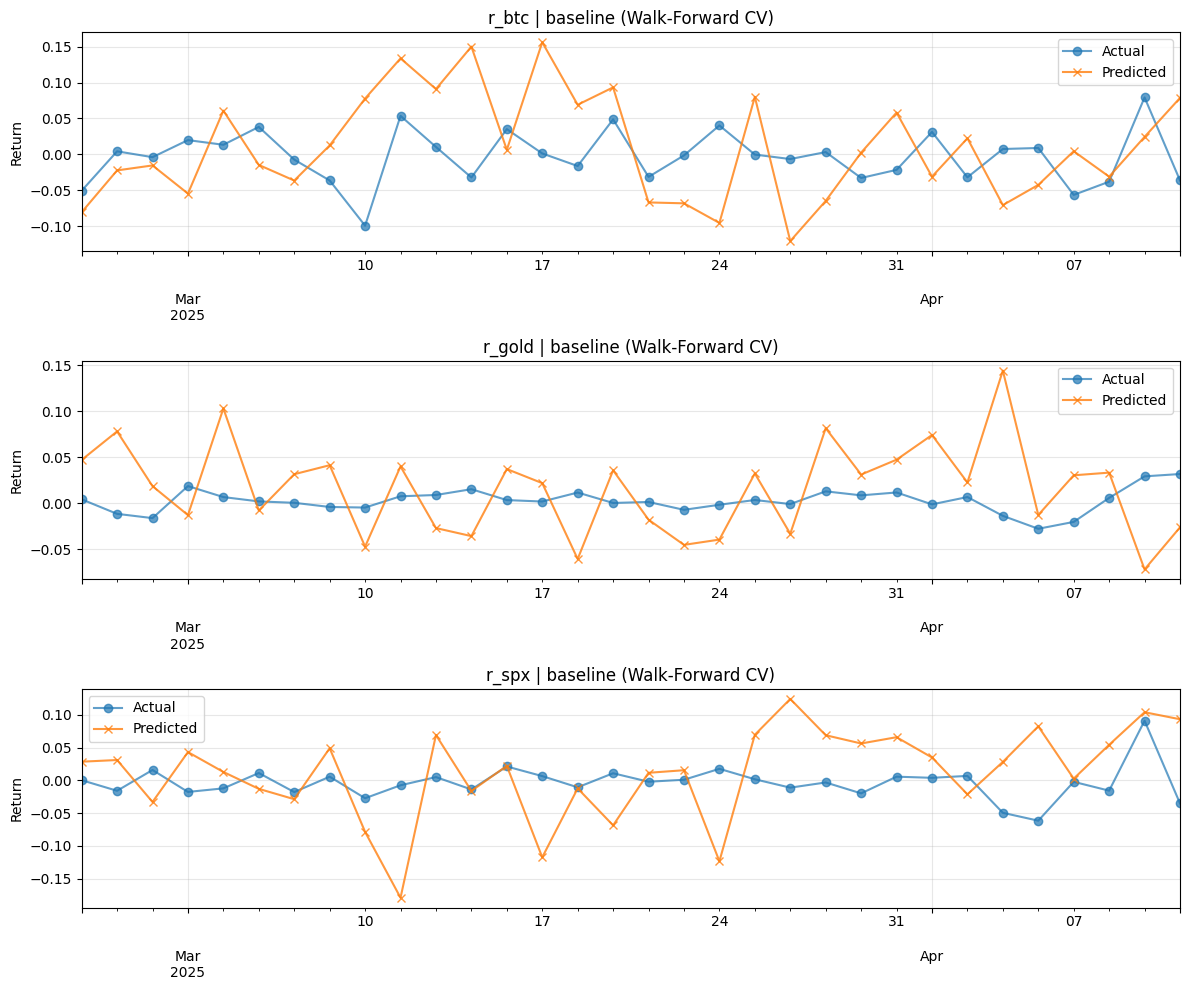

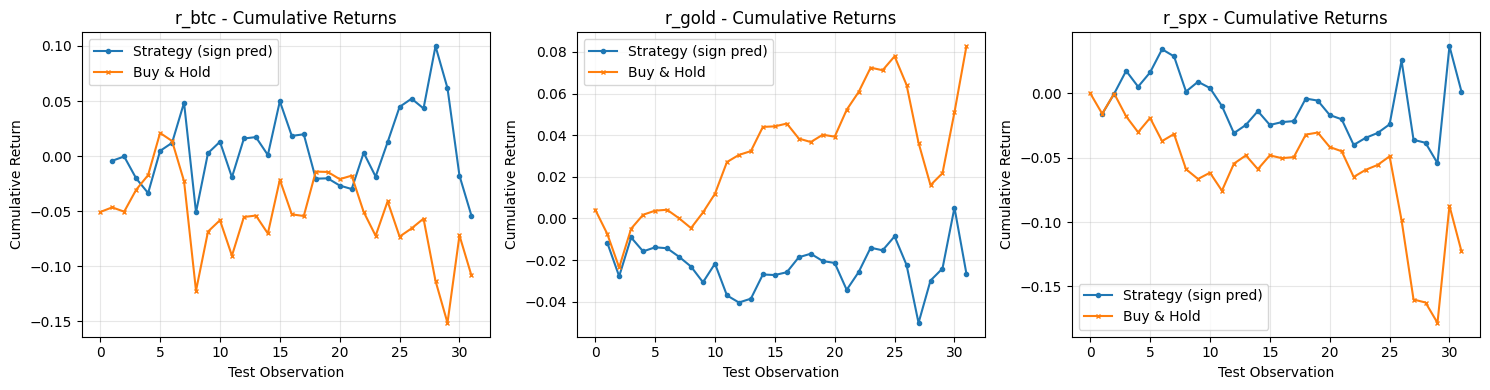

In [29]:
# Find best model type by average RMSE
if not comparison_df.empty:
    best_model_type = comparison_df.groupby("Model")["RMSE"].mean().idxmin()
    print(f"Best model type (lowest avg RMSE): {best_model_type}")
else:
    best_model_type = "baseline"
    print("No successful runs; using baseline placeholder.")

# Plot predictions vs actuals
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
for idx, asset in enumerate(assets):
    res = results.get(best_model_type, {}).get(asset)
    if not res or "error" in res:
        axes[idx].set_title(f"{asset}: no predictions")
        continue
    ax = axes[idx]
    res["actuals"].plot(ax=ax, label="Actual", alpha=0.7, marker='o')
    res["predictions"].plot(ax=ax, label="Predicted", alpha=0.8, marker='x')
    ax.set_title(f"{asset} | {best_model_type} (Walk-Forward CV)")
    ax.set_ylabel("Return")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cumulative returns using sign of predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, asset in enumerate(assets):
    res = results.get(best_model_type, {}).get(asset)
    if not res or "error" in res:
        axes[idx].set_title(f"{asset}: no returns plot")
        continue
    actuals = res["actuals"]
    preds = res["predictions"]
    strategy = (np.sign(preds.shift(1)) * actuals).cumsum()
    buy_hold = actuals.cumsum()
    axes[idx].plot(strategy.values, label="Strategy (sign pred)", marker='o', markersize=3)
    axes[idx].plot(buy_hold.values, label="Buy & Hold", marker='x', markersize=3)
    axes[idx].set_title(f"{asset} - Cumulative Returns")
    axes[idx].set_xlabel("Test Observation")
    axes[idx].set_ylabel("Cumulative Return")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

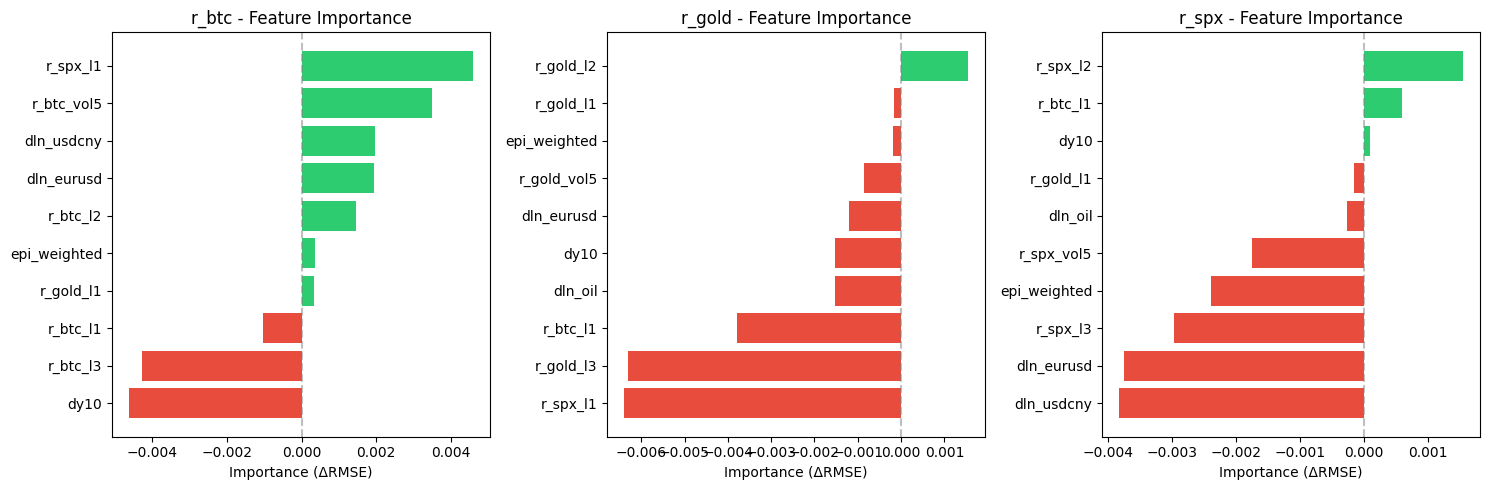


FEATURE IMPORTANCE SUMMARY

r_btc:
  Useful features (positive importance): ['r_spx_l1', 'r_btc_vol5', 'dln_usdcny', 'dln_eurusd', 'r_btc_l2']

r_gold:
  Useful features (positive importance): ['r_gold_l2']

r_spx:
  Useful features (positive importance): ['r_spx_l2', 'r_btc_l1', 'dy10']


In [31]:
# Visualize feature importance
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, asset in enumerate(assets):
    ax = axes[idx]
    imp_df = importance_results[asset].head(10)  # Top 10 features
    
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in imp_df['importance']]
    bars = ax.barh(imp_df['feature'], imp_df['importance'], color=colors)
    ax.set_xlabel('Importance (ΔRMSE)')
    ax.set_title(f'{asset} - Feature Importance')
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Summary of important features
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 60)
for asset in assets:
    imp_df = importance_results[asset]
    positive_features = imp_df[imp_df['importance'] > 0]['feature'].tolist()
    print(f"\n{asset}:")
    print(f"  Useful features (positive importance): {positive_features[:5]}")

## 9. Notes / Next Steps

- **Walk-forward validation** provides more realistic out-of-sample performance estimates than single train/test splits
- **Feature importance** via permutation helps identify which features add signal vs noise
- Features with **positive importance** increase error when shuffled (they're useful)
- Features with **negative importance** may be adding noise - consider removing them
- The `±` values show standard deviation across folds, indicating result stability